# **K-Fold Cross Validation**

## Intuition

When we use **Train-Test Split**, our model’s performance depends heavily on **which samples** go into training and which into testing.  
If we get an unlucky split, the model may look worse (or better) than it really is.

To make evaluation **more reliable**, we use **Cross-Validation** — specifically, **K-Fold Cross Validation**.

---

##  What is K-Fold Cross Validation?

In **K-Fold Cross Validation**, the dataset is divided into **K equal parts (folds)**.

The model is trained and tested **K times**:
- Each time, one fold acts as the **test set**
- The remaining **K-1 folds** act as the **training set**

Finally, we take the **average performance** across all K runs.

---

##  Example (for K = 5)

| Fold | Training Data | Testing Data |
|------|----------------|---------------|
| 1 | F2, F3, F4, F5 | F1 |
| 2 | F1, F3, F4, F5 | F2 |
| 3 | F1, F2, F4, F5 | F3 |
| 4 | F1, F2, F3, F5 | F4 |
| 5 | F1, F2, F3, F4 | F5 |

Each sample gets a chance to be in the test set exactly once

---

##  Why Do We Need It?

- More **robust performance estimate**  
- Uses **entire dataset** for both training and validation  
- Reduces dependency on random split  
- Especially useful for **small datasets**

---

##  Formula / Concept

If you have `N` samples and `K = 5`,  
then each fold will contain about `N / K` samples.

Each iteration gives one **validation score**, and we take the **mean**:

$$\text{CV Score} = \frac{1}{K} \sum_{i=1}^{K} Accuracy_i$$$$$$


# **Implementation**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# create a synthetic dataset
np.random.seed(42)
X = np.random.randn(20, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

# convert to DataFrame
df = pd.DataFrame(np.hstack((X, y.reshape(-1, 1))), columns=["Feature1", "Feature2", "Label"])
df.head()

,Feature1,Feature2,Label
0,0.496714,-0.138264,1.0
1,0.647689,1.523030,1.0
2,-0.234153,-0.234137,0.0
3,1.579213,0.767435,1.0
4,-0.469474,0.542560,1.0


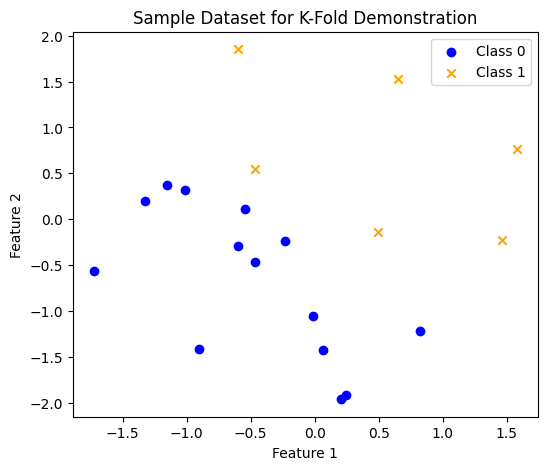

In [7]:
## Visualizing the Dataset
plt.figure(figsize=(6, 5))
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='blue', label='Class 0')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='orange', label='Class 1', marker='x')
plt.title("Sample Dataset for K-Fold Demonstration")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

K-Fold splitting logic.

    Parameters:
    -----------
    X : np.ndarray - Feature matrix
    y : np.ndarray - Labels
    k : int - Number of folds
    shuffle : bool - Shuffle before splitting
    random_state : int - Seed for reproducibility

    Returns:
    --------
    folds : list of tuples - [(train_indices, test_indices), ...]

In [8]:
# Implement K-Fold Cross Validation
def k_fold_split(X, y, k=5, shuffle=True, random_state=None):
    n_samples = len(X)

    # this create an array of indicies from 0 to n-1
    indices = np.arange(n_samples)

    if shuffle:
        # random seed for generating same output
        if random_state is not None:
            np.random.seed(random_state)
        # occurs shuffling
        np.random.shuffle(indices)

    # finding the size of each fold
    # this line creates an array of k elements
    fold_sizes = np.full(k, n_samples // k, dtype=int)
    # distribute any remaining samples one by one
    fold_sizes[:n_samples % k] += 1

    # list to store the train and test indices for each fold
    folds = []
    # keeps track of the starting index for the current fold
    current = 0

    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        test_indices = indices[start:stop]
        train_indices = np.concatenate([indices[:start], indices[stop:]])

        folds.append((train_indices, test_indices))

        current = stop

    return folds

# **Comparision**

In [12]:
# Demo of custom K-Fold split
folds = k_fold_split(X, y, k=5, shuffle=True, random_state=42)

for i, (train_idx, test_idx) in enumerate(folds, 1):
    print(f"Fold {i}:")
    print("Train indices:", train_idx)
    print("Test indices:", test_idx)
    print("----------------------------------------------------------------")

Fold 1:
Train indices: [ 8  5 11  3 18 16 13  2  9 19  4 12  7 10 14  6]
Test indices: [ 0 17 15  1]
----------------------------------------------------------------
Fold 2:
Train indices: [ 0 17 15  1 18 16 13  2  9 19  4 12  7 10 14  6]
Test indices: [ 8  5 11  3]
----------------------------------------------------------------
Fold 3:
Train indices: [ 0 17 15  1  8  5 11  3  9 19  4 12  7 10 14  6]
Test indices: [18 16 13  2]
----------------------------------------------------------------
Fold 4:
Train indices: [ 0 17 15  1  8  5 11  3 18 16 13  2  7 10 14  6]
Test indices: [ 9 19  4 12]
----------------------------------------------------------------
Fold 5:
Train indices: [ 0 17 15  1  8  5 11  3 18 16 13  2  9 19  4 12]
Test indices: [ 7 10 14  6]
----------------------------------------------------------------


In [13]:
# Compare with scikit learn
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for i, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    print(f"Fold {i}:")
    print("Train indices:", train_idx)
    print("Test indices:", test_idx)
    print("----------------------------------------------------------------")

Fold 1:
Train indices: [ 2  3  4  5  6  7  8  9 10 11 12 13 14 16 18 19]
Test indices: [ 0  1 15 17]
----------------------------------------------------------------
Fold 2:
Train indices: [ 0  1  2  4  6  7  9 10 12 13 14 15 16 17 18 19]
Test indices: [ 3  5  8 11]
----------------------------------------------------------------
Fold 3:
Train indices: [ 0  1  3  4  5  6  7  8  9 10 11 12 14 15 17 19]
Test indices: [ 2 13 16 18]
----------------------------------------------------------------
Fold 4:
Train indices: [ 0  1  2  3  5  6  7  8 10 11 13 14 15 16 17 18]
Test indices: [ 4  9 12 19]
----------------------------------------------------------------
Fold 5:
Train indices: [ 0  1  2  3  4  5  8  9 11 12 13 15 16 17 18 19]
Test indices: [ 6  7 10 14]
----------------------------------------------------------------
